In [1]:
import CMGDB

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
import numpy as np
import time
import math
import csv

In [26]:
# Leslie map without padding
def f(x):
    th1 = 23.5 # 20.0
    th2 = 23.5 # 20.0
    return [(th1 * x[0] + th2 * x[1]) * math.exp (-0.1 * (x[0] + x[1])), 0.7 * x[0]]

def F(rect):
    x0_min = rect[0]
    x1_min = rect[1]
    x0_max = rect[2]
    x1_max = rect[3]
    y1 = f([x0_min, x1_min])
    y2 = f([x0_max, x1_min])
    y3 = f([x0_min, x1_max])
    y4 = f([x0_max, x1_max])
    y0_min = min([y1[0], y2[0], y3[0], y4[0]])
    y0_max = max([y1[0], y2[0], y3[0], y4[0]])
    y1_min = min([y1[1], y2[1], y3[1], y4[1]])
    y1_max = max([y1[1], y2[1], y3[1], y4[1]])
    return [y0_min, y1_min, y0_max, y1_max]

In [ ]:
# Sweep subdiv_init from 10 to 20 to find the minimum value that yields
# a Morse graph with (at least) two minimal nodes (attractors).
subdiv_limit = 10000
lower_bounds = [-0.001, -0.001]
upper_bounds = [90.0, 70.0]

min_subdiv_init = None
for subdiv_init in range(10, 21):
    subdiv_min = subdiv_init
    subdiv_max = subdiv_init

    model = CMGDB.Model(subdiv_min, subdiv_max,
                        subdiv_init, subdiv_limit,
                        lower_bounds, upper_bounds, F)
    morse_graph, _ = CMGDB.ComputeMorseGraph(model)

    # Minimal nodes
    minimal_nodes = [v for v in morse_graph.vertices()
                      if len(morse_graph.adjacencies(v)) == 0]
    n_min = len(minimal_nodes)
    print(f"subdiv_init={subdiv_init}: {morse_graph.num_vertices()} vertices, "
          f"{n_min} minimal node(s)")

    if n_min >= 2 and min_subdiv_init is None:
        min_subdiv_init = subdiv_init
        break  # remove this if you want the full sweep up to 20

print(f"\nMinimum subdiv_init with >=2 minimal nodes: {min_subdiv_init}")

if min_subdiv_init is None:
    min_subdiv_init = subdiv_init
    print(f"No subdiv_init in 10..20 yielded >=2 minimal nodes; using {min_subdiv_init} downstream.")

# Recompute at the found value so morse_graph / model are available downstream
subdiv_init = min_subdiv_init
subdiv_min = subdiv_init
subdiv_max = subdiv_init
model = CMGDB.Model(subdiv_min, subdiv_max,
                    subdiv_init, subdiv_limit,
                    lower_bounds, upper_bounds, F)
morse_graph, map_graph = CMGDB.ComputeMorseGraph(model)

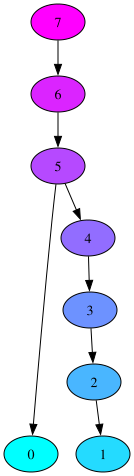

In [ ]:
CMGDB.PlotMorseGraph(morse_graph, cmap=matplotlib.cm.cool)

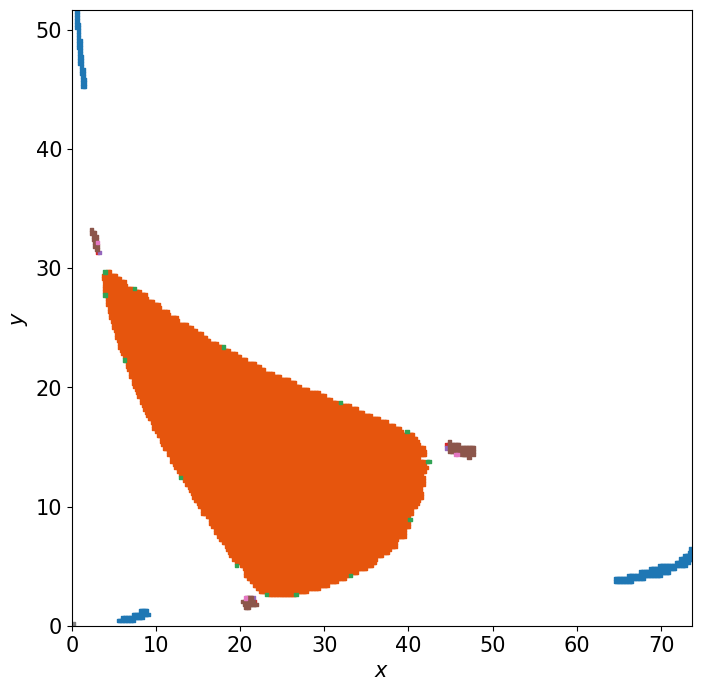

In [ ]:
CMGDB.PlotMorseSets(morse_graph)

In [18]:
# Leslie map with padding

def f(x):
    th1 = 23.5 # 20.0
    th2 = 23.5 # 20.0
    return [(th1 * x[0] + th2 * x[1]) * math.exp (-0.1 * (x[0] + x[1])), 0.7 * x[0]]

def F(rect):
    x0_min = rect[0]
    x1_min = rect[1]
    x0_max = rect[2]
    x1_max = rect[3]
    h_x0 = x0_max - x0_min
    h_x1 = x1_max - x1_min
    y1 = f([x0_min, x1_min])
    y2 = f([x0_max, x1_min])
    y3 = f([x0_min, x1_max])
    y4 = f([x0_max, x1_max])
    y0_min = min([y1[0], y2[0], y3[0], y4[0]]) - h_x0
    y0_max = max([y1[0], y2[0], y3[0], y4[0]]) + h_x0
    y1_min = min([y1[1], y2[1], y3[1], y4[1]]) - h_x1
    y1_max = max([y1[1], y2[1], y3[1], y4[1]]) + h_x1
    return [y0_min, y1_min, y0_max, y1_max]

In [ ]:
# Sweep subdiv_init from 10 to 20 to find the minimum value that yields
# a Morse graph with (at least) two minimal nodes (attractors).
subdiv_limit = 10000
lower_bounds = [-0.001, -0.001]
upper_bounds = [90.0, 70.0]

min_subdiv_init = None
for subdiv_init in range(10, 21):
    subdiv_min = subdiv_init
    subdiv_max = subdiv_init

    model = CMGDB.Model(subdiv_min, subdiv_max,
                        subdiv_init, subdiv_limit,
                        lower_bounds, upper_bounds, F)
    morse_graph, _ = CMGDB.ComputeMorseGraph(model)

    # Minimal nodes
    minimal_nodes = [v for v in morse_graph.vertices()
                      if len(morse_graph.adjacencies(v)) == 0]
    n_min = len(minimal_nodes)
    print(f"subdiv_init={subdiv_init}: {morse_graph.num_vertices()} vertices, "
          f"{n_min} minimal node(s)")

    if n_min >= 2 and min_subdiv_init is None:
        min_subdiv_init = subdiv_init
        break  # remove this if you want the full sweep up to 20

print(f"\nMinimum subdiv_init with >=2 minimal nodes: {min_subdiv_init}")

if min_subdiv_init is None:
    min_subdiv_init = subdiv_init
    print(f"No subdiv_init in 10..20 yielded >=2 minimal nodes; using {min_subdiv_init} downstream.")

# Recompute at the found value so morse_graph / model are available downstream
subdiv_init = min_subdiv_init
subdiv_min = subdiv_init
subdiv_max = subdiv_init
model = CMGDB.Model(subdiv_min, subdiv_max,
                    subdiv_init, subdiv_limit,
                    lower_bounds, upper_bounds, F)
morse_graph, map_graph = CMGDB.ComputeMorseGraph(model)

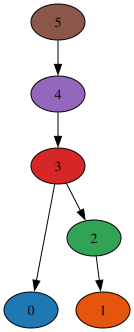

In [20]:
CMGDB.PlotMorseGraph(morse_graph)

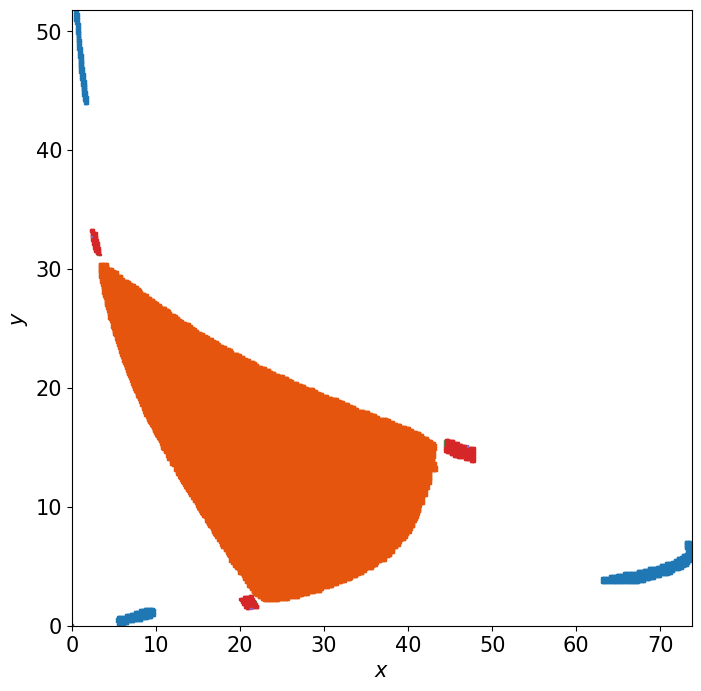

In [21]:
CMGDB.PlotMorseSets(morse_graph)

Patrick's parameter

In [22]:
# parameters from the paper
def f(x):
    th1 = 23.5 # 20.0
    th2 = 23.5 # 20.0
    return [(th1 * x[0] + th2 * x[1]) * math.exp (-0.1 * (x[0] + x[1])), 0.7 * x[0]]

def F(rect):
    x0_min = rect[0]
    x1_min = rect[1]
    x0_max = rect[2]
    x1_max = rect[3]
    y1 = f([x0_min, x1_min])
    y2 = f([x0_max, x1_min])
    y3 = f([x0_min, x1_max])
    y4 = f([x0_max, x1_max])
    y0_min = min([y1[0], y2[0], y3[0], y4[0]])
    y0_max = max([y1[0], y2[0], y3[0], y4[0]])
    y1_min = min([y1[1], y2[1], y3[1], y4[1]])
    y1_max = max([y1[1], y2[1], y3[1], y4[1]])
    return [y0_min, y1_min, y0_max, y1_max]

In [ ]:
# Sweep subdiv_init from 10 to 20 to find the minimum value that yields
# a Morse graph with (at least) two minimal nodes (attractors).
subdiv_limit = 10000
lower_bounds = [-0.001, -0.001]
upper_bounds = [90.0, 70.0]

min_subdiv_init = None
for subdiv_init in range(10, 21):
    subdiv_min = subdiv_init
    subdiv_max = subdiv_init

    model = CMGDB.Model(subdiv_min, subdiv_max,
                        subdiv_init, subdiv_limit,
                        lower_bounds, upper_bounds, F)
    morse_graph, _ = CMGDB.ComputeMorseGraph(model)

    # Minimal nodes
    minimal_nodes = [v for v in morse_graph.vertices()
                      if len(morse_graph.adjacencies(v)) == 0]
    n_min = len(minimal_nodes)
    print(f"subdiv_init={subdiv_init}: {morse_graph.num_vertices()} vertices, "
          f"{n_min} minimal node(s)")

    if n_min >= 2 and min_subdiv_init is None:
        min_subdiv_init = subdiv_init
        break  # remove this if you want the full sweep up to 20

print(f"\nMinimum subdiv_init with >=2 minimal nodes: {min_subdiv_init}")

if min_subdiv_init is None:
    min_subdiv_init = subdiv_init
    print(f"No subdiv_init in 10..20 yielded >=2 minimal nodes; using {min_subdiv_init} downstream.")

# Recompute at the found value so morse_graph / model are available downstream
subdiv_init = min_subdiv_init
subdiv_min = subdiv_init
subdiv_max = subdiv_init
model = CMGDB.Model(subdiv_min, subdiv_max,
                    subdiv_init, subdiv_limit,
                    lower_bounds, upper_bounds, F)
morse_graph, map_graph = CMGDB.ComputeMorseGraph(model)

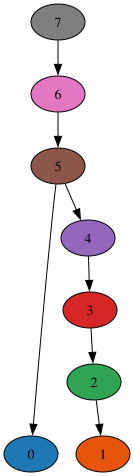

In [24]:
CMGDB.PlotMorseGraph(morse_graph)

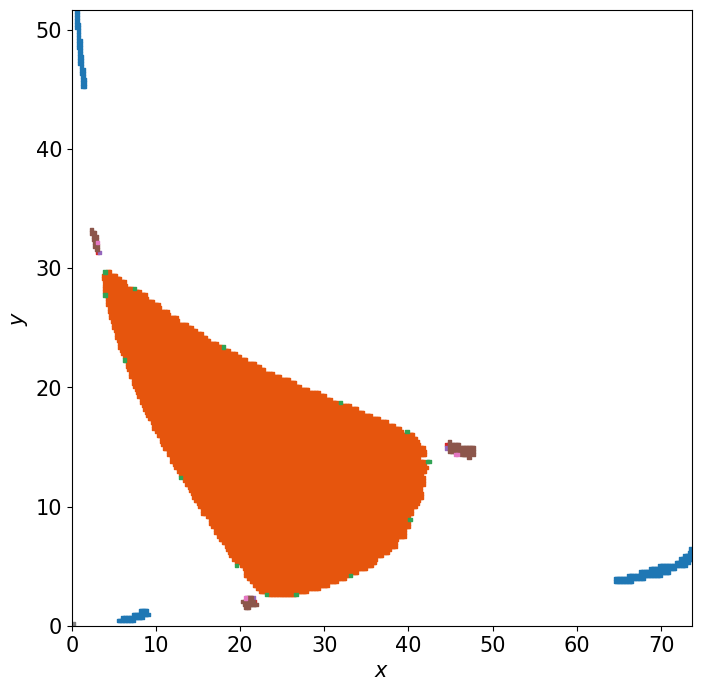

In [25]:
CMGDB.PlotMorseSets(morse_graph)